**XGBOOST DIELECTRICS PREDICTOR**

This notebook contains the code required to train a xgboost regressor predictor for dielectric anisotropy values

In [ ]:
import pandas as pd
from rdkit.Chem import PandasTools
import pickle 
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, SubsetRandomSampler
from sklearn.model_selection import train_test_split, KFold, cross_val_predict, KFold, GridSearchCV, cross_val_score
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.stats import gaussian_kde
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor

import numpy as np
import pandas as pd
from pathlib import Path
from typing import Tuple, Optional
import warnings

from sklearn.pipeline import Pipeline


In [ ]:
# import custom modules 

from dielectric_ml import chemnet, fionet, plotnet, neurnet, prednet

In [ ]:
# load data

file_path = 'new_DE_data.xlsx'
df = pd.read_excel(file_path)

In [ ]:
# Convert to numeric and drop invalid rows 
df['target'] = pd.to_numeric(df['Δε'], errors='coerce')
df = df.dropna(subset=['target']).reset_index(drop=True)

print(f"Retained {len(df)} samples")

PandasTools.RenderImagesInAllDataFrames(images=True)
PandasTools.AddMoleculeColumnToFrame(df, smilesCol='smiles')
pd.set_option('display.max_rows', 10)

target = df['Δε'] 

# 3135 dataset samples retained with their corresponding del_e
df

In [ ]:
# generate new fps if needed

fps = chemnet.get_fingerprints_new(df, 
                                smiles_column = 'smiles', 
                                n_jobs=1,
                               fp_size=1024, 
                               use_3D=True)

You can load fingerprints here if you are sure that the data matches

In [ ]:
# load fingerprints
with open ('new_de_fps.pkl', 'rb') as f:
    fps = pickle.load(f)

In [ ]:
fps

In [ ]:
# TRAINING METRICS FOR THE XGBOOST REGRESSOR

TEST_SIZE = 0.2
N_FOLDS = 5
RANDOM_STATE = 42

In [13]:
n_molecules = len(target)
fps_valid = {}

for name, X in fps.items():
    if X.shape[0] == n_molecules:
        fps_valid[name] = X
    else:
        print(f"Skipping {name}: {X.shape[0]} rows vs {n_molecules} expected")

print(f"\nUsing {len(fps_valid)}/{len(fps)} fingerprints with {n_molecules} molecules")



Using 28/28 fingerprints with 3135 molecules


In [14]:
train_idx, test_idx = train_test_split(
    np.arange(n_molecules),
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

if hasattr(target, 'values'):
    target = target.values
    
y_train = target[train_idx]
y_test = target[test_idx]


In [15]:
def evaluate_fingerprint(X_train, y_train, X_test, y_test, n_folds=5, random_state=42):
    """
    Train models via CV on training set, evaluate each fold's model on:
    - Its own training fold (train RMSE)
    - Held-out test set (test RMSE)
    
    Returns mean/std for both train and test RMSE.
    """
    cv = KFold(n_splits=n_folds, shuffle=True, random_state=random_state)
    
    train_rmse_scores = []
    test_rmse_scores = []
    
    for fold_train_idx, fold_val_idx in cv.split(X_train):
        model = XGBRegressor(
            n_estimators=500,
            max_depth=10,
            learning_rate=0.01,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=random_state,
            n_jobs=1
        )
        
        model.fit(X_train[fold_train_idx], y_train[fold_train_idx])
        
        # Train RMSE (on the fold's training data)
        y_train_pred = model.predict(X_train[fold_train_idx])
        train_rmse = np.sqrt(mean_squared_error(y_train[fold_train_idx], y_train_pred))
        train_rmse_scores.append(train_rmse)
        
        # Test RMSE (on held-out test set)
        y_test_pred = model.predict(X_test)
        test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
        test_rmse_scores.append(test_rmse)
    
    return {
        'train_mean': np.mean(train_rmse_scores),
        'train_std': np.std(train_rmse_scores),
        'test_mean': np.mean(test_rmse_scores),
        'test_std': np.std(test_rmse_scores),
    }


**Training Loop**

In [ ]:
results = {}


for name, X in fps_valid.items():
    print(f"Evaluating {name}...")
    
    if not np.isfinite(X).all():
        n_bad = (~np.isfinite(X)).sum()
        print(f"  Warning: {n_bad} non-finite values")
    
    try:
        X_train = X[train_idx]
        X_test = X[test_idx]
        
        results[name] = evaluate_fingerprint(
            X_train, y_train, X_test, y_test,
            n_folds=N_FOLDS, random_state=RANDOM_STATE
        )
        
        r = results[name]
        print(f"  Train RMSE: {r['train_mean']:.3f} ± {r['train_std']:.3f}")
        print(f"  Test RMSE:  {r['test_mean']:.3f} ± {r['test_std']:.3f}")
        
    except Exception as e:
        print(f"  Failed: {e}")


In [ ]:
results

**SAVE/LOAD RESULTS**

In [17]:
# write results info

import pickle
"""
with open('xgboost_results.pkl', 'wb') as f:
    pickle.dump(results, f)
"""
"""
with open('xgboost_results.pkl', 'rb') as f:
    results = pickle.load(f)
""" 

In [18]:
test_results = {
    name: {
        "test_mean": float(vals["test_mean"]),
        "test_std": float(vals["test_std"]),
    }
    for name, vals in results.items()
}

In [ ]:
test_results

**COMPARE XGBOOST PREDICTIONS AGAINST M-M CALCS** 

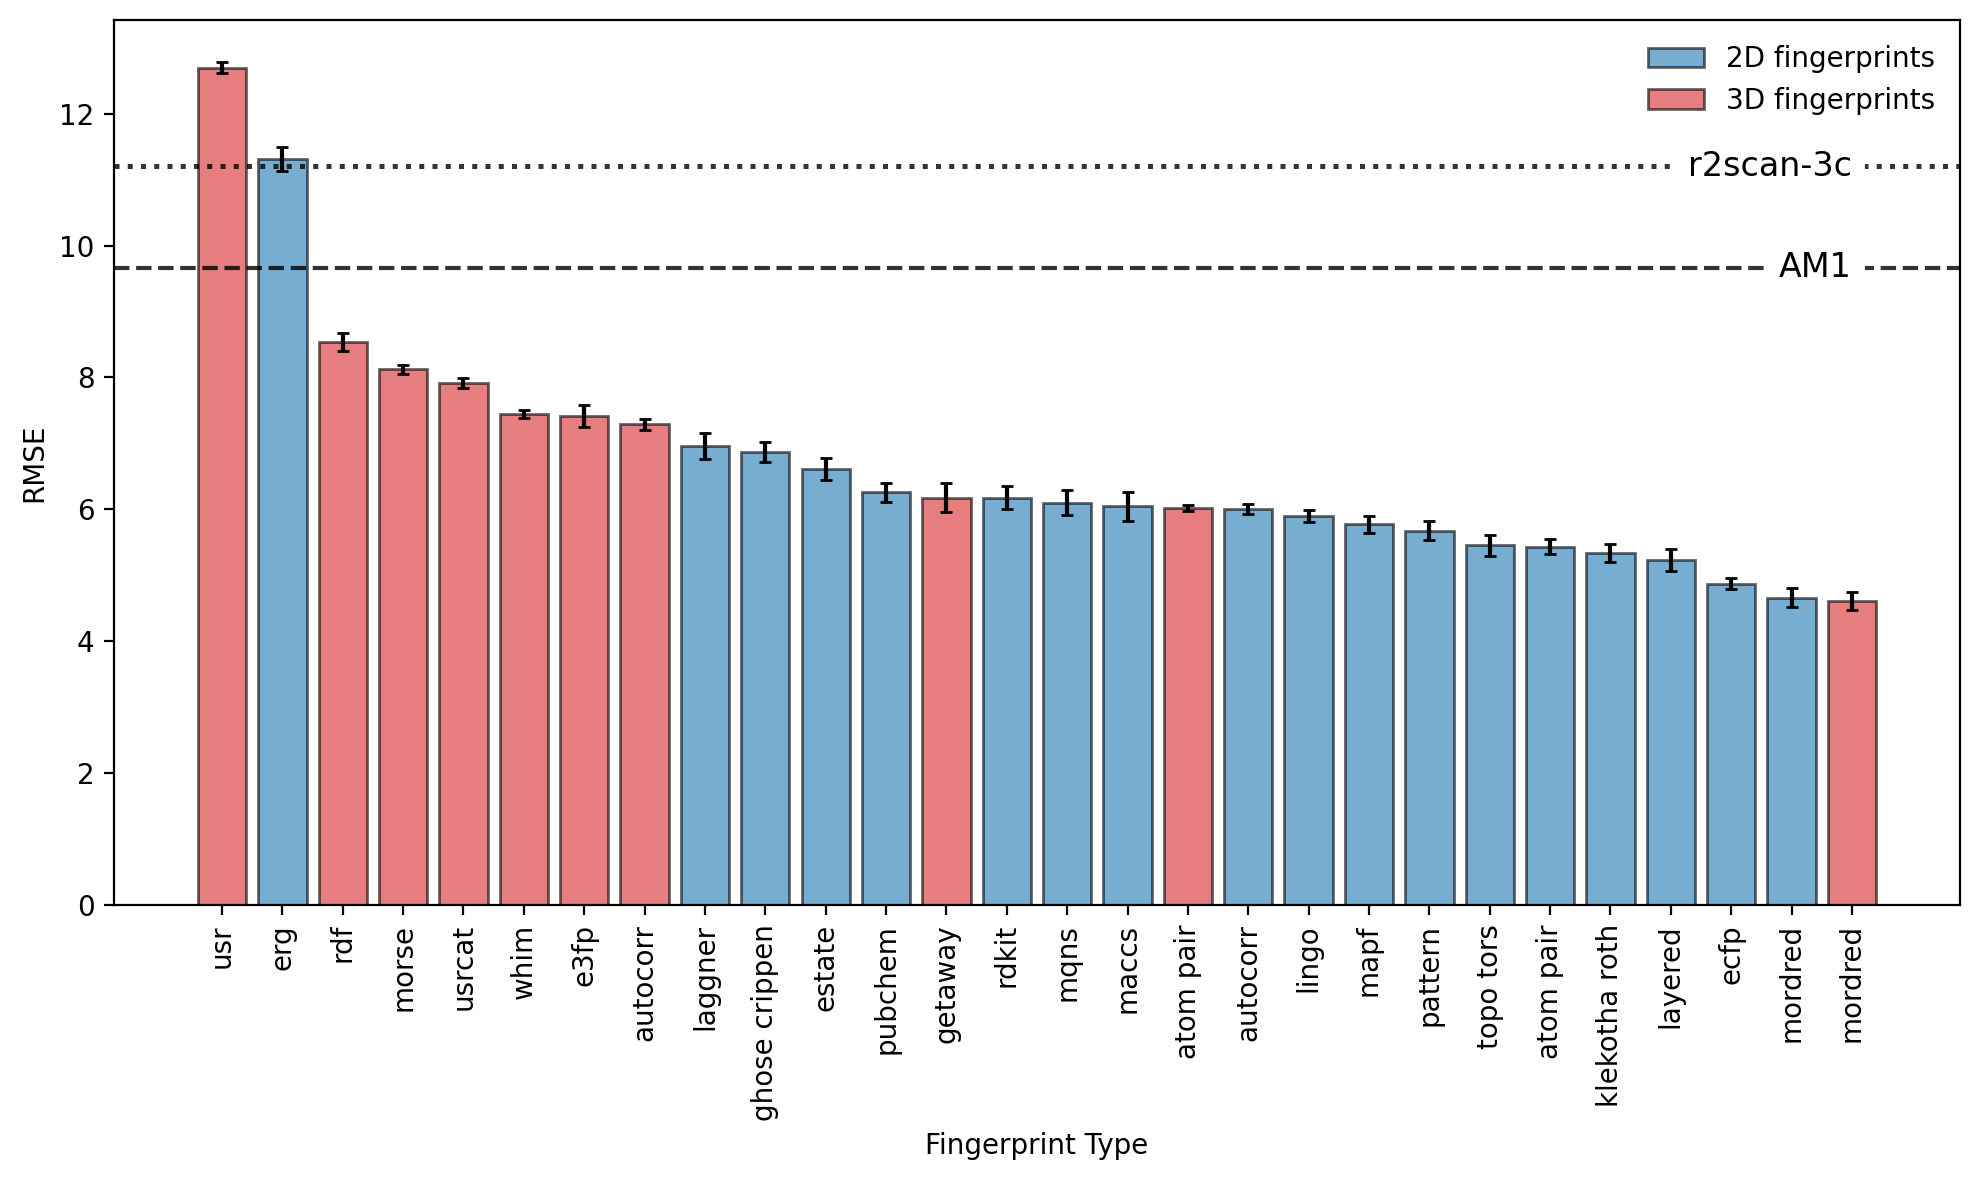

In [24]:
sorted_items = sorted(results.items(), key=lambda x: x[1]['test_mean'], reverse=True)
labels = [item[0] for item in sorted_items]

test_means = np.array([results[l]['test_mean'] for l in labels])
test_stds = np.array([results[l]['test_std'] for l in labels])

labels_clean = [
    l.replace('_3D', '').replace('_', ' ').replace('fingerprint', '').strip()
    for l in labels
]

colors = ["tab:red" if "3D" in label else "tab:blue" for label in labels]

x = np.arange(len(labels))

plt.figure(figsize=(10, 6), dpi=200)
plt.bar(
    x, test_means,
    yerr=test_stds, capsize=2,
    color=colors, edgecolor='k', alpha=0.6
)
plt.xticks(x, labels_clean, rotation=90)
plt.ylabel("RMSE")
plt.xlabel("Fingerprint Type")

# Reference lines
rmse_am1 = 9.66
rmse_r2scan = 11.2
plt.axhline(rmse_am1, color="k", linestyle="--", linewidth=1.5, alpha=0.8)
plt.text(len(labels) - 1, rmse_am1, 'AM1', fontsize=12, va='center', ha='right', backgroundcolor='w')
plt.axhline(rmse_r2scan, color="k", linestyle=":", linewidth=1.8, alpha=0.8)
plt.text(len(labels) - 1, rmse_r2scan, 'r2scan-3c', fontsize=12, va='center', ha='right', backgroundcolor='w')

# Legend for 2D/3D distinction
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="tab:blue", edgecolor='k', alpha=0.6, label="2D fingerprints"),
    Patch(facecolor="tab:red", edgecolor='k', alpha=0.6, label="3D fingerprints"),
]
plt.legend(handles=legend_elements, frameon=False, loc="upper right")

plt.tight_layout()
plt.savefig("data/xg_boost_test_rmse2.svg")
plt.show()